# Customer Churn Prediction Using Machine Learning

## Project Overview

Customer churn refers to the situation where a customer stops using or subscribing to a company's products or services. Predicting customer churn is an important business problem because identifying customers who are likely to leave can allow organisations to take appropriate retention measures.

This project develops a machine-learning model for predicting whether a customer is likely to churn based on information about the customer's demographics, services, contract, account, and billing characteristics.

The project uses the Telco Customer Churn dataset. Exploratory data analysis will first be conducted to understand the dataset and identify patterns associated with customer churn. The data will then be cleaned and prepared for machine-learning modelling. Different classification algorithms will be trained and evaluated, after which the best-performing model will be selected.

The final trained model will be integrated into a simple prediction application that allows a user to enter customer information and receive a churn prediction together with the estimated probability of churn.

## Project Objectives

The objectives of this project are to:

1. Explore and preprocess customer data for churn prediction.
2. Develop and compare machine-learning classification models for predicting customer churn.
3. Evaluate and select the best-performing model based on appropriate performance metrics.
4. Develop a simple application for predicting the churn risk of individual customers.

## Expected Outcome

The expected outcome is a functional customer churn prediction system capable of receiving customer information and predicting whether the customer is likely to churn.

## Project Workflow

The project follows the following machine-learning workflow:

**Dataset → Data Understanding → Data Cleaning → Exploratory Data Analysis → Feature Preparation → Train/Test Split → Model Training → Model Evaluation → Model Selection → Model Saving → Prediction Application**

Each stage will be documented and explained to ensure that the machine-learning process is transparent and reproducible.

In [1]:
# Import the libraries required for data manipulation, visualisation,
# numerical computation, and machine-learning development.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display all columns when inspecting the dataset.
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Loading the Dataset

The dataset is stored in the project's `data` directory. Using a defined file path makes the notebook easier to reproduce and ensures that the same dataset location is used throughout the analysis.

In [2]:
from pathlib import Path

# Define the location of the customer churn dataset.
# The notebook and the "data" folder are both located in the
# project root directory, so we can access the dataset directly
# through the "data" folder.

DATA_PATH = Path("data/Telco-Customer-Churn.csv")

# Confirm that the dataset exists before loading it.
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Please confirm that Telco-Customer-Churn.csv is inside the data folder."
    )

print(f"Dataset found: {DATA_PATH}")

Dataset found: data\Telco-Customer-Churn.csv


In [3]:
# Load the Telco Customer Churn dataset into a pandas DataFrame.
# The DataFrame will be used throughout the project for data
# inspection, cleaning, visualisation, and machine-learning analysis.

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
# Display the first five records to verify that the dataset
# has been loaded correctly.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Understanding the Dataset

Before beginning data preprocessing, the dataset is examined to understand its structure, size, variables, and overall quality. This step helps identify potential data-quality issues that need to be addressed before machine-learning models are trained.

In [5]:
# Determine the number of observations and variables in the dataset.
# The number of rows represents customers, while the number of columns
# represents the available customer attributes and the churn outcome.

rows, columns = df.shape

print(f"Number of customers: {rows}")
print(f"Number of variables: {columns}")

Number of customers: 7043
Number of variables: 21


### Dataset Variables

The dataset contains demographic, account, service, billing, and customer-retention information. Examining the column names helps us understand the variables available for predicting customer churn.

In [6]:
# Display all column names in the dataset.
# This allows us to identify the available customer characteristics
# and the target variable that the model will predict.

print("Dataset columns:")
for column in df.columns:
    print(f"- {column}")

Dataset columns:
- customerID
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges
- Churn


### Data Types

Different machine-learning variables require different forms of preprocessing. Numerical variables can generally be used directly or scaled, while categorical variables must usually be encoded into numerical representations before they can be used by most machine-learning algorithms.

The data types of the variables are therefore examined before preprocessing.

In [7]:
# Display the data type of each variable.
# This helps us distinguish numerical variables from categorical
# variables and identify columns that may require conversion.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Missing Values

Missing values can affect the reliability of machine-learning models. We therefore check each variable to determine whether customer records contain missing observations.

In [8]:
# Count the number of missing values in each column.
# A value greater than zero indicates that the corresponding variable
# contains missing observations that may need to be handled.

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Duplicate Records

Duplicate customer records can introduce bias into model training because the same observation may be counted more than once. The dataset is therefore checked for duplicated rows.

In [9]:
# Count completely duplicated rows in the dataset.
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 0


### Target Variable: Churn

The `Churn` variable represents the outcome that the machine-learning model is required to predict. A value of `Yes` indicates that the customer churned, while `No` indicates that the customer remained with the service.

The distribution of the target variable is examined to determine whether churned and non-churned customers are reasonably represented in the dataset.

In [10]:
# Count the number of customers in each churn category.
churn_counts = df["Churn"].value_counts()

print("Customer churn distribution:")
print(churn_counts)

Customer churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


### Visualising Customer Churn

A bar chart is used to visualise the distribution of the target variable. This provides a simple graphical representation of the proportion of customers who churned compared with those who remained with the company.

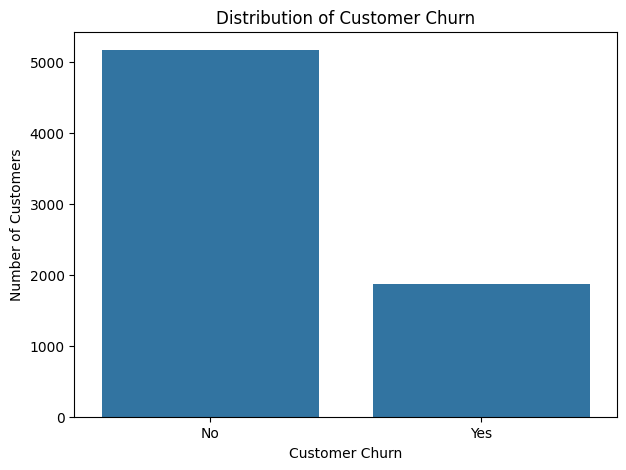

In [11]:
# Create a bar chart showing the number of customers in each churn category.

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Distribution of Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Number of Customers")

plt.show()

## 3. Investigating the TotalCharges Variable

The `TotalCharges` variable represents the total amount charged to each customer. Although this variable is expected to contain numerical values, the initial data inspection shows that Pandas has interpreted it as a string variable.

This may indicate that some records contain blank spaces or other non-numerical values. The variable is therefore investigated before conversion so that any problematic records can be handled appropriately.

In [12]:
# Display a sample of values from TotalCharges to examine
# how the variable is currently represented in the dataset.

df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str

In [13]:
# Identify TotalCharges values that cannot be converted to numbers.
# Errors are converted to NaN temporarily so that problematic
# values can be counted without changing the original dataset.

total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = total_charges_numeric.isna().sum()

print(f"Values that cannot be converted to numbers: {invalid_total_charges}")

Values that cannot be converted to numbers: 11


In [14]:
# Display the customer records where TotalCharges could not
# be interpreted as a numerical value.

df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## 4. Data Cleaning

The investigation of `TotalCharges` identified 11 records containing blank values. All affected customers have a tenure of zero months, indicating that they are newly registered customers who have not yet accumulated total charges.

These records represent valid customers rather than duplicate or invalid observations. Therefore, the customer records will be retained while the `TotalCharges` variable is converted from text to a numerical format. The resulting missing values will then be handled using an appropriate imputation method.

In [15]:
# Create a numerical version of TotalCharges.
# Values that cannot be interpreted as numbers are converted to NaN.
# This allows the blank TotalCharges entries to be treated as missing
# numerical observations.

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges converted to numerical format.")
print(f"Missing TotalCharges values: {df['TotalCharges'].isna().sum()}")

TotalCharges converted to numerical format.
Missing TotalCharges values: 11


### Handling Missing TotalCharges Values

The 11 missing `TotalCharges` observations correspond to customers with zero months of tenure. Since these customers have not completed a month of service, their accumulated total charge can reasonably be represented as zero.

The missing values are therefore replaced with zero while retaining the affected customer records.

In [16]:
# Replace missing TotalCharges values with zero.
# These missing values belong to customers with zero tenure,
# for whom no accumulated total charge has been recorded.

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(f"Remaining missing TotalCharges values: {df['TotalCharges'].isna().sum()}")

Remaining missing TotalCharges values: 0


In [17]:
# Check the data type of TotalCharges after conversion.
print(f"TotalCharges data type: {df['TotalCharges'].dtype}")

# Display the updated structure of the dataset.
df.info()

TotalCharges data type: float64
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  704

In [18]:
# Display the previously affected records to verify that their
# TotalCharges values have been handled correctly.

df.loc[
    df["tenure"] == 0,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].head(15)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is conducted to identify patterns and relationships between customer characteristics and churn. The analysis focuses on variables that may provide useful information for understanding why customers leave the service.

The findings from this stage will also help guide the selection and preparation of variables for machine-learning modelling.

In [19]:
# Confirm the final number of observations and variables after data cleaning.
print(f"Dataset size: {df.shape[0]} customers × {df.shape[1]} variables")

# Check for remaining missing values.
print(f"Total missing values: {df.isna().sum().sum()}")

# Check for duplicate records.
print(f"Total duplicate records: {df.duplicated().sum()}")

Dataset size: 7043 customers × 21 variables
Total missing values: 0
Total duplicate records: 0


### Customer Churn by Contract Type

Contract type represents the customer's commitment period with the service provider. Customers may have month-to-month, one-year, or two-year contracts.

The churn rate for each contract category is examined to determine whether customer commitment is associated with retention.

In [20]:
# Calculate the proportion of customers who churn within each contract type.
# Using proportions rather than raw counts allows us to compare the
# categories fairly despite differences in their group sizes.

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


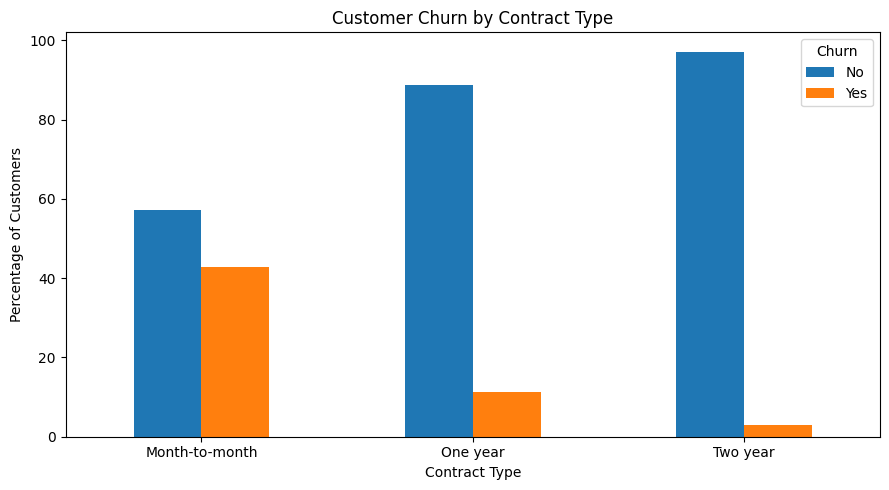

In [21]:
# Visualise the churn percentage for each contract type.

contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### Customer Churn by Tenure

Tenure represents the number of months a customer has remained with the service provider. Customers with shorter tenure may have different churn behaviour from long-term customers.

Customer tenure is therefore examined to determine whether the length of the customer relationship is associated with churn.

In [22]:
# Create meaningful tenure groups for exploratory analysis.
# Grouping tenure makes it easier to compare churn behaviour among
# new, developing, and long-term customers.

tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

# Calculate the churn percentage within each tenure group.
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


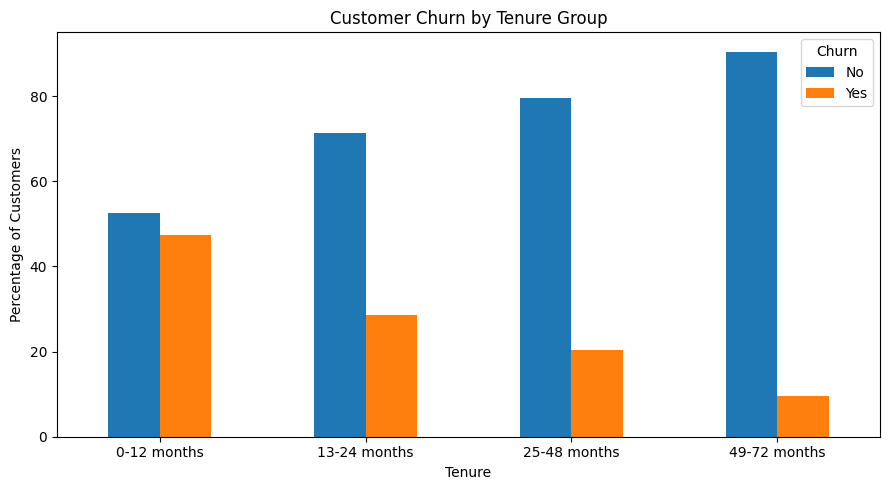

In [23]:
# Visualise churn across customer tenure groups.

tenure_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### Monthly Charges and Customer Churn

Monthly charges represent the amount billed to customers each month. Comparing monthly charges between customers who churned and those who remained can help identify whether pricing or service cost may be associated with customer retention.

In [24]:
# Compare monthly charges between customers who churned
# and customers who remained with the service.

df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Churn,,,,,
No,5174,61.265124,64.425,18.25,118.75
Yes,1869,74.441332,79.650,18.85,118.35


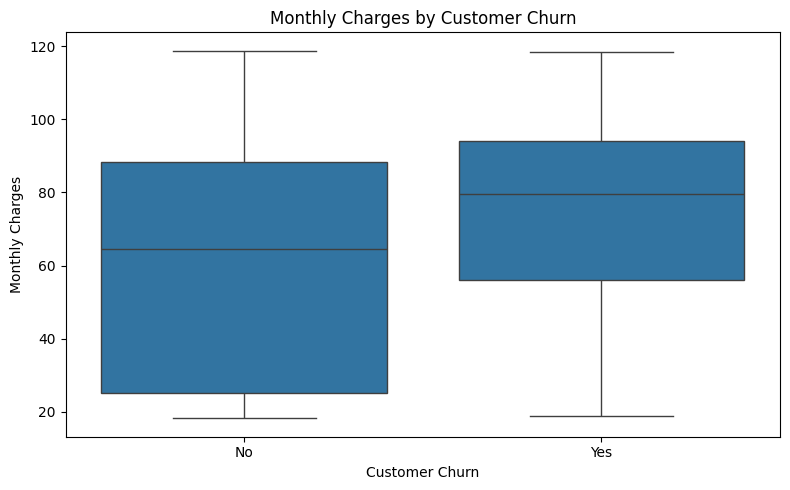

In [25]:
# Visualise the distribution of monthly charges for each churn category.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

### Customer Churn by Internet Service

Internet service type is examined because different service technologies may have different customer experiences, costs, and service requirements. The analysis compares churn rates across the available internet service categories.

In [26]:
# Calculate churn percentages for each internet service category.

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


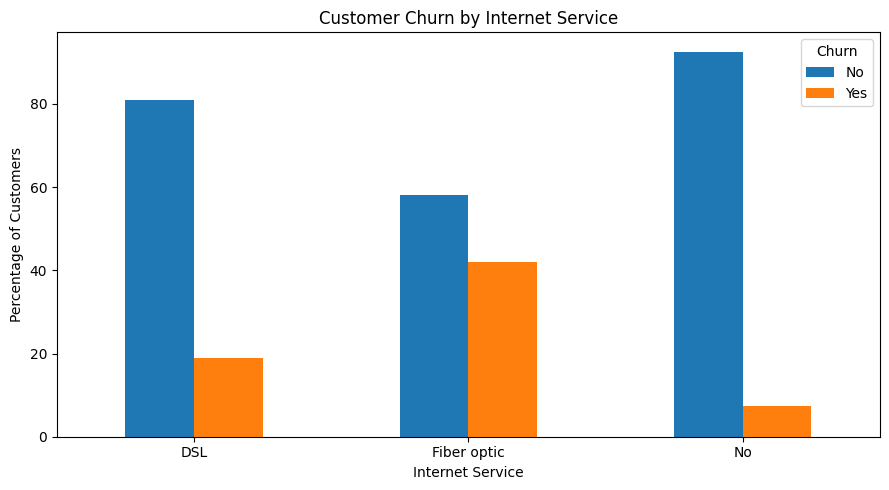

In [27]:
# Visualise churn according to internet service type.

internet_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### Technical Support and Customer Churn

Technical support is an additional service available to customers. Its relationship with churn is examined to determine whether access to technical support is associated with customer retention.

In [28]:
# Calculate the percentage of customers who churn within
# each technical-support category.

support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


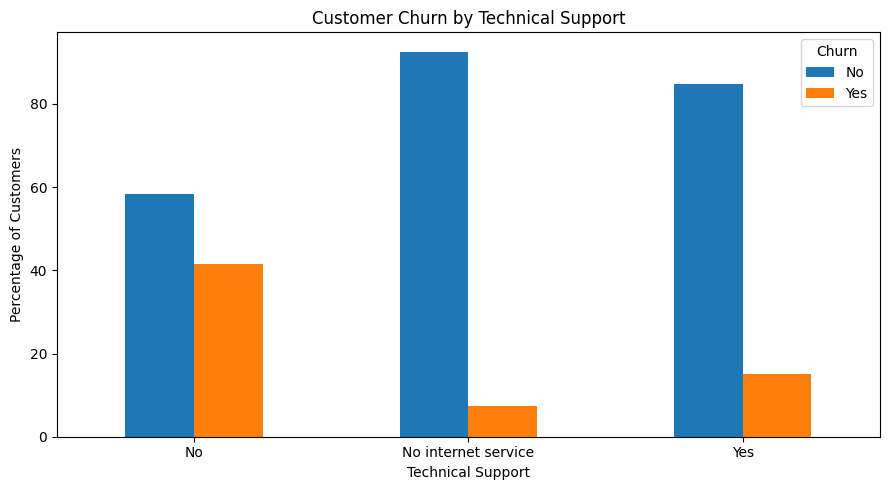

In [29]:
# Visualise churn according to technical support status.

support_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Churn by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### Customer Churn by Payment Method

Payment method is examined to determine whether customer churn differs across the available payment options. This may reveal behavioural differences between customers using different payment arrangements.

In [30]:
# Calculate churn percentages for each payment method.

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


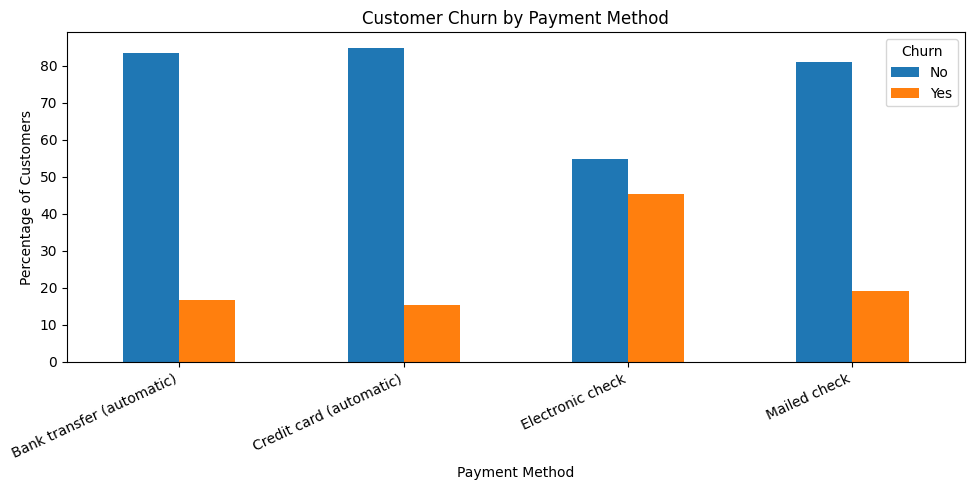

In [31]:
# Visualise customer churn by payment method.

payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

## 6. Feature Preparation

Machine-learning models require a clear separation between the input variables and the outcome to be predicted.

The `Churn` variable is selected as the target variable, while the remaining relevant customer characteristics are treated as input features. The `customerID` variable is excluded because it is an identifier rather than a meaningful customer characteristic.

The `TenureGroup` variable created during exploratory analysis is also excluded from modelling because it was created specifically for visual analysis, while the original numerical `tenure` variable provides the underlying information directly.

In [32]:
# Create the feature matrix by removing the target variable and
# variables that should not be used as predictive features.

X = df.drop(
    columns=["Churn", "customerID", "TenureGroup"]
)

# Create the target variable containing the outcome we want to predict.
y = df["Churn"]

print(f"Number of input features: {X.shape[1]}")
print(f"Number of target observations: {y.shape[0]}")

Number of input features: 19
Number of target observations: 7043


### Encoding the Target Variable

The target variable contains two categorical outcomes: `Yes` for customers who churned and `No` for customers who remained with the service. These categories are converted into binary numerical values, where `0` represents no churn and `1` represents churn.

This allows the classification models to interpret the prediction task as a binary classification problem.

In [33]:
# Convert the churn outcome into binary numerical values.
# 0 represents customers who did not churn, while 1 represents
# customers who churned.

y = y.map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


## 7. Identifying Feature Types

The dataset contains both numerical and categorical variables. Numerical variables can be processed using numerical transformations, while categorical variables need to be converted into numerical representations before being supplied to the machine-learning algorithms.

The feature types are identified automatically from the dataset rather than manually listing every column. This makes the preprocessing workflow easier to maintain.

In [34]:
# Identify numerical and categorical columns automatically.

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 8. Splitting the Dataset

The dataset is divided into training and testing subsets before machine-learning preprocessing and model training.

Eighty percent of the observations are used for training, while the remaining twenty percent are reserved for evaluating the final models on previously unseen customer records.

Stratified sampling is used to preserve the proportion of churned and non-churned customers in both subsets. This is important because the target variable is not evenly distributed.

In [35]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing subsets.
# Stratification preserves the original churn distribution in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training observations: {X_train.shape[0]}")
print(f"Testing observations: {X_test.shape[0]}")

Training observations: 5634
Testing observations: 1409


## 9. Data Preprocessing Pipeline

The machine-learning models cannot directly process categorical text values. Therefore, categorical variables are transformed using one-hot encoding, which represents each category as a numerical indicator.

Numerical variables are standardised using `StandardScaler`. Standardisation places numerical features on comparable scales and is particularly useful for algorithms that are sensitive to feature magnitude.

A Scikit-learn `ColumnTransformer` is used to apply the appropriate transformation to each feature type. Keeping preprocessing inside a pipeline helps ensure that the same transformations are applied consistently during model training and future predictions.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define the preprocessing steps for numerical and categorical features.

numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Apply each transformation to the appropriate columns.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 10. Model Development

### 10.1 Logistic Regression

Logistic Regression is selected as the first classification model because the project involves binary prediction: whether a customer will churn or not.

It also provides a useful baseline model against which more complex classification algorithms can be compared.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create a machine-learning pipeline that first preprocesses the data
# and then trains a Logistic Regression classifier.

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


### Training the Logistic Regression Model

The Logistic Regression pipeline is trained using only the training dataset. The testing dataset remains unseen during training so that it can provide an unbiased evaluation of the model's ability to generalise to new customers.

In [38]:
# Train the Logistic Regression model using the training data.
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [39]:
# Generate churn predictions for the unseen test dataset.

y_pred_logistic = logistic_model.predict(X_test)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_logistic)}")

Predictions generated successfully.
Number of predictions: 1409


## 11. Model Evaluation

Model evaluation is used to determine how well the trained classifier performs on customer records that were not used during training.

Several evaluation metrics are used because no single metric provides a complete view of model performance. Accuracy measures the overall proportion of correct predictions, while precision, recall, and F1-score provide more detailed information about the model's ability to identify customers who churn.

The ROC-AUC score is also considered because it measures the model's ability to distinguish between customers who churn and those who do not across different classification thresholds.

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [41]:
# Calculate the main classification metrics using the predictions
# generated from the Logistic Regression model.

accuracy = accuracy_score(y_test, y_pred_logistic)

precision = precision_score(y_test, y_pred_logistic)

recall = recall_score(y_test, y_pred_logistic)

f1 = f1_score(y_test, y_pred_logistic)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.7381
Precision: 0.5043
Recall   : 0.7834
F1-score : 0.6136


### Why Recall is Important

In a customer churn prediction system, failing to identify a customer who is actually going to leave can result in a missed opportunity to take retention action.

Recall is therefore particularly important because it measures the proportion of actual churned customers that the model successfully identifies.

A model with high recall is able to identify a larger proportion of customers who are at risk of leaving, even if some customers predicted as churners ultimately remain with the company.

In [42]:
# Generate a detailed classification report showing precision,
# recall, F1-score, and support for both target classes.

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### ROC-AUC Evaluation

The ROC-AUC metric is used to assess how well the Logistic Regression model separates customers who churn from customers who do not churn.

Unlike accuracy, ROC-AUC evaluates the model across different probability thresholds. A higher ROC-AUC value indicates stronger discrimination between the two classes.

In [43]:
# Generate the probability that each test customer will churn.
# The second column represents the probability of class 1 (Churn = Yes).

y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Calculate the ROC-AUC score.
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8416


### Confusion Matrix

A confusion matrix provides a detailed view of the model's classification results by showing the number of correct and incorrect predictions for each class.

The matrix contains true negatives, false positives, false negatives, and true positives. In this project, particular attention is given to false negatives because they represent customers who actually churned but were incorrectly predicted as non-churners.

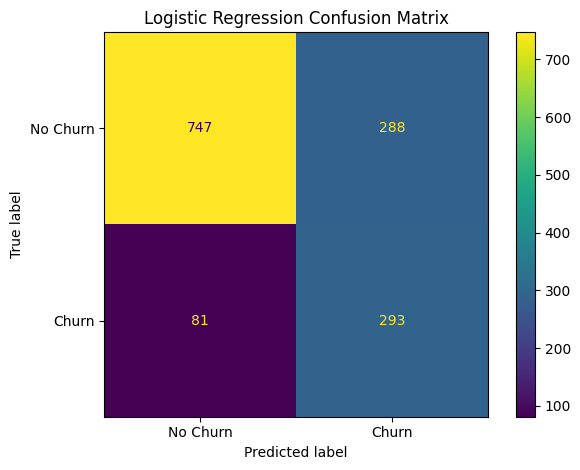

In [44]:
# Calculate the confusion matrix.
cm = confusion_matrix(y_test, y_pred_logistic)

# Display the confusion matrix as a visual plot.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [45]:
# Extract the four confusion-matrix components.

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

True Negatives : 747
False Positives: 288
False Negatives: 81
True Positives : 293


In [46]:
# Store the Logistic Regression evaluation results in a structured
# dictionary so that they can later be compared with other models.

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7381121362668559,
 'Precision': 0.504302925989673,
 'Recall': 0.7834224598930482,
 'F1-Score': 0.6136125654450262,
 'ROC-AUC': 0.8416388953473353}

## 12. Random Forest Model

Random Forest is selected as the second classification algorithm for comparison with Logistic Regression. The algorithm combines multiple decision trees to produce a more robust prediction.

Random Forest can capture nonlinear relationships between customer characteristics and churn, making it a useful alternative to the linear decision boundary used by Logistic Regression.

The same training and testing data will be used so that the two models can be compared fairly.

In [47]:
from sklearn.ensemble import RandomForestClassifier

# Create a machine-learning pipeline containing the same preprocessing
# procedure used for Logistic Regression, followed by a Random Forest
# classifier.

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [48]:
# Train the Random Forest model using the same training dataset
# used for Logistic Regression.

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [49]:
# Generate predictions for the unseen test dataset.

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_rf)}")

Random Forest predictions generated successfully.
Number of predictions: 1409


In [50]:
# Generate churn probabilities for ROC-AUC evaluation.

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest probabilities generated successfully.")

Random Forest probabilities generated successfully.


## 12.1 Random Forest Model Evaluation

The Random Forest model is evaluated using the same performance metrics applied to Logistic Regression. Using the same test dataset and evaluation criteria allows the two models to be compared fairly.

The evaluation focuses on accuracy, precision, recall, F1-score, and ROC-AUC. Particular attention is given to recall because identifying customers who are actually at risk of churn is an important objective of the prediction system.

In [51]:
# Calculate the main evaluation metrics for the Random Forest model.

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Accuracy : 0.7708
Precision: 0.5606
Recall   : 0.6310
F1-score : 0.5937
ROC-AUC  : 0.8220


In [52]:
# Generate a detailed classification report for the Random Forest model.

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



### Random Forest Confusion Matrix

The confusion matrix is used to examine the types of correct and incorrect predictions produced by the Random Forest model. Particular attention is given to false negatives because these represent customers who actually churned but were incorrectly classified as non-churners.

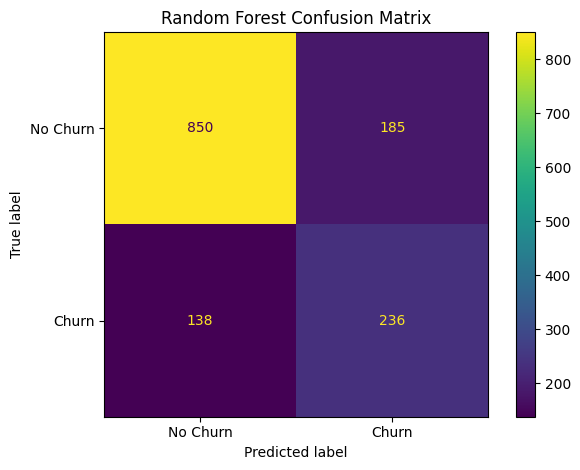

In [53]:
# Calculate the Random Forest confusion matrix.
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display the confusion matrix.
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp_rf.plot()

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [54]:
# Extract the four components of the Random Forest confusion matrix.

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print(f"True Negatives : {tn_rf}")
print(f"False Positives: {fp_rf}")
print(f"False Negatives: {fn_rf}")
print(f"True Positives : {tp_rf}")

True Negatives : 850
False Positives: 185
False Negatives: 138
True Positives : 236


## 13. Model Comparison

The Logistic Regression and Random Forest models are compared using the same evaluation metrics and test dataset. This comparison provides an objective basis for selecting the model that will be used in the final customer churn prediction application.

In [55]:
# Store the evaluation results for both machine-learning models.

random_forest_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "ROC-AUC": rf_roc_auc
}

# Combine the results into a single DataFrame.
model_comparison = pd.DataFrame([
    logistic_results,
    random_forest_results
])

# Display the results rounded to four decimal places.
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8416
1,Random Forest,0.7708,0.5606,0.6310,0.5937,0.8220


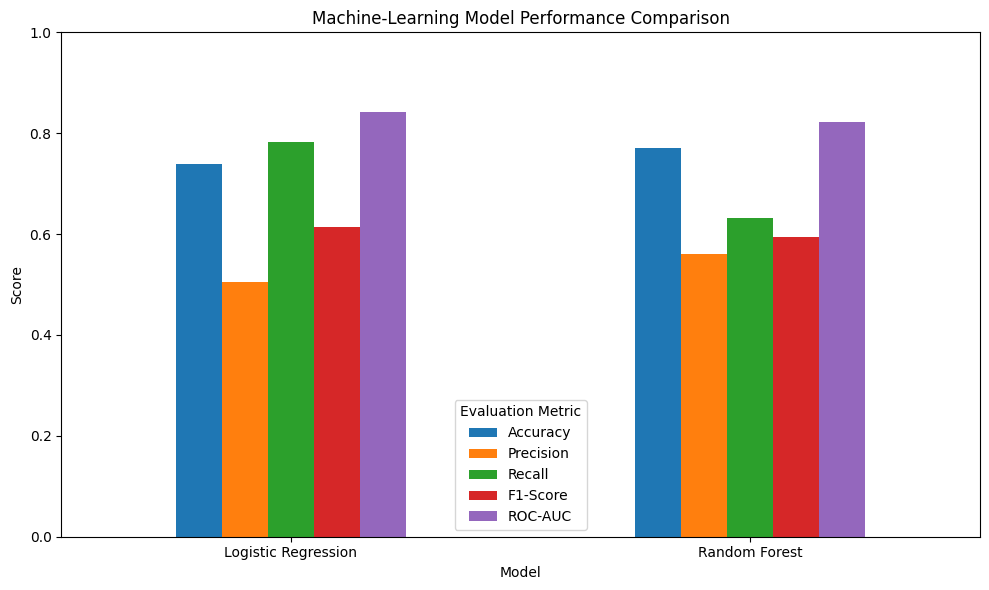

In [56]:
# Select the main performance metrics for visual comparison.

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_plot = model_comparison.set_index("Model")[metrics]

# Create a grouped bar chart comparing the two models.

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine-Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(title="Evaluation Metric")
plt.tight_layout()
plt.show()

## 14. Final Model Selection

The model comparison showed that Random Forest achieved higher accuracy (77.08%) and precision (56.06%) than Logistic Regression. However, Logistic Regression achieved higher recall (78.34%), F1-score (61.36%), and ROC-AUC (84.16%).

Since the primary purpose of the system is to identify customers who are at risk of churn, recall is considered particularly important. A false negative represents a customer who actually churns but is incorrectly classified as a customer who will remain.

Logistic Regression correctly identified 293 of the 374 customers who churned in the test dataset, compared with 236 identified by Random Forest.

Based on the evaluation results and the objective of identifying potential churners, Logistic Regression was selected as the final predictive model for the customer churn prediction system.

## 15. Feature Influence Analysis

Feature influence analysis is conducted to identify the variables that contribute most strongly to the Logistic Regression model's predictions.

The coefficients of the trained Logistic Regression classifier are examined after preprocessing. Positive coefficients indicate features associated with a higher predicted probability of churn, while negative coefficients indicate features associated with a lower predicted probability of churn.

The analysis provides an interpretable view of the factors considered by the final model.

In [57]:
# Extract the trained preprocessing component from the final model.
trained_preprocessor = logistic_model.named_steps["preprocessor"]

# Extract the trained Logistic Regression classifier.
trained_classifier = logistic_model.named_steps["classifier"]

# Get the names of the features after preprocessing.
feature_names = trained_preprocessor.get_feature_names_out()

# Get the Logistic Regression coefficients.
coefficients = trained_classifier.coef_[0]

# Create a DataFrame containing each feature and its coefficient.
feature_influence = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort features by coefficient.
feature_influence = feature_influence.sort_values(
    "Coefficient",
    ascending=False
)

feature_influence.head(15)

,Feature,Coefficient
16,categorical__InternetService_Fiber optic,0.707981
36,categorical__Contract_Month-to-month,0.657713
3,numerical__TotalCharges,0.489698
35,categorical__StreamingMovies_Yes,0.275392
32,categorical__StreamingTV_Yes,0.262166
43,categorical__PaymentMethod_Electronic check,0.240275
18,categorical__OnlineSecurity_No,0.199030
27,categorical__TechSupport_No,0.165519
14,categorical__MultipleLines_Yes,0.132843
26,categorical__DeviceProtection_Yes,0.074190


In [58]:
# Display the features with the strongest negative coefficients.

feature_influence.tail(15).sort_values(
    "Coefficient",
    ascending=True
)

,Feature,Coefficient
1,numerical__tenure,-1.154434
38,categorical__Contract_Two year,-0.775518
2,numerical__MonthlyCharges,-0.676114
15,categorical__InternetService_DSL,-0.622465
25,categorical__DeviceProtection_No internet service,-0.275403
22,categorical__OnlineBackup_No internet service,-0.275403
34,categorical__StreamingMovies_No internet service,-0.275403
17,categorical__InternetService_No,-0.275403
31,categorical__StreamingTV_No internet service,-0.275403
19,categorical__OnlineSecurity_No internet service,-0.275403


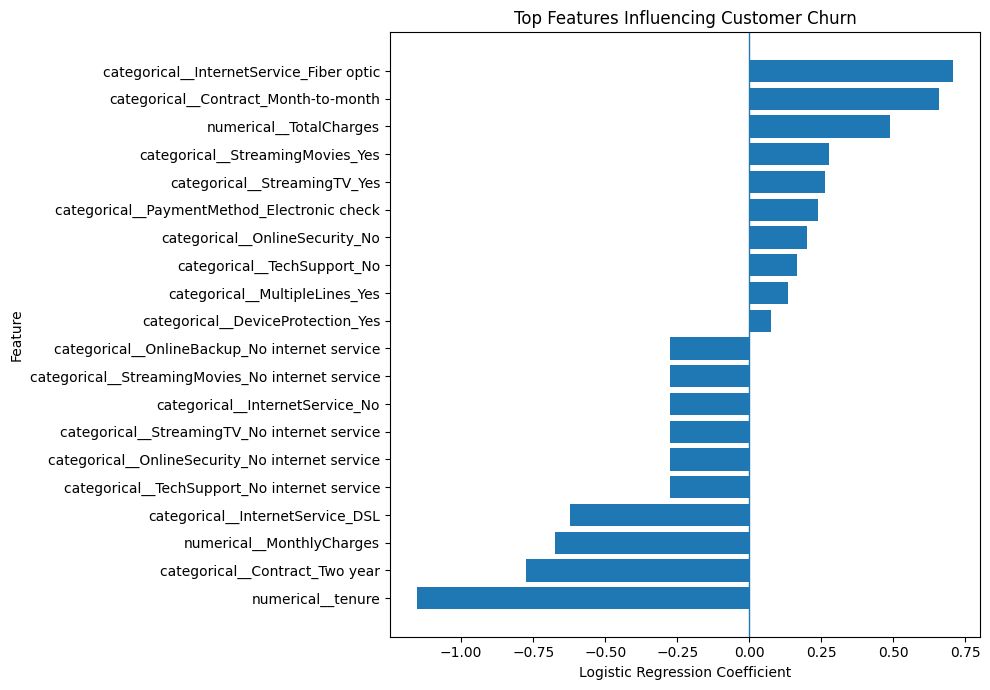

In [59]:
# Select the 10 features with the strongest positive and negative coefficients.

top_positive = feature_influence.head(10)

top_negative = feature_influence.tail(10)

top_features = pd.concat([
    top_positive,
    top_negative
]).sort_values("Coefficient")

# Plot the selected feature coefficients.

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [60]:
import joblib
from pathlib import Path

# Create a directory for trained machine-learning models.
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# Save the complete preprocessing + Logistic Regression pipeline.
MODEL_PATH = MODEL_DIR / "customer_churn_model.pkl"

joblib.dump(
    logistic_model,
    MODEL_PATH
)

print(f"Final model saved successfully to: {MODEL_PATH}")

Final model saved successfully to: models\customer_churn_model.pkl


In [61]:
# Load the saved model from disk.
loaded_model = joblib.load(MODEL_PATH)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [62]:
# Generate predictions using the reloaded model.
test_predictions = loaded_model.predict(X_test)

# Confirm that the reloaded model produces the same predictions
# as the original trained model.

predictions_match = np.array_equal(
    test_predictions,
    y_pred_logistic
)

print(f"Predictions from saved model match original model: {predictions_match}")

Predictions from saved model match original model: True
